# Regional snow-line elevation (RSLE)

Python conversion of [`plotSnowLine.m`](./plotSnowLine.m). The calculation uses the WGS84 / UTM zone 44N DEM and Sentinel-2 fractional snow cover (FSC) GeoTIFFs in `ROIbb2/`.

FSC values are interpreted as follows: `0` is no snow, `1..100` is snow, and values above `100` are cloud/invalid.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from scipy.optimize import minimize_scalar

DATA_DIR = Path("ROIbb2")
DEM_PATH = DATA_DIR / "dem.tif"

with rasterio.open(DEM_PATH) as src:
    dem = src.read(1).astype(float)
    pixel_area_km2 = 1e-6 * abs(src.transform.a * src.transform.e)
    
print(f"DEM shape: {dem.shape}; pixel area: {pixel_area_km2:g} km²")

DEM shape: (2652, 3139); pixel area: 0.0004 km²


## Snow-line calculation

For a candidate elevation `zs`, the objective is the number of snow-covered pixels below `zs` plus no-snow pixels above `zs`, following Krajci et al. (2014). Here we also implement an optional snowline elevation calculation accounting for subpixel snow cover.

In [5]:
def load_fsc(date):
    """Load one FSC product and return its array."""
    path = DATA_DIR / f"fsc{date}.tif"
    with rasterio.open(path) as src:
        fsc = src.read(1)
    return fsc

def analyze_snowline(date,fractional=True):
    """Compute binned pixel areas and the optimum RSLE for one FSC date - using fractional snow cover if requested."""
    fsc = load_fsc(date)
    fsca = fsc / 100
    no_snow = fsc == 0
    snow = (fsc > 0) & (fsc <= 100)
    cloud = fsc > 100

    z1 = round(float(np.nanmin(dem)) / 100) * 100
    z2 = round(float(np.nanmax(dem)) / 100) * 100
    edges = np.arange(z1, z2 + 100, 100, dtype=float)
    centers = edges[:-1] + 50

    if fractional:
        snow_counts, _ = np.histogram(dem[snow], bins=edges, weights=fsca[snow])
    else:
        snow_counts, _ = np.histogram(dem[snow], bins=edges)
    cloud_counts, _ = np.histogram(dem[cloud], bins=edges)
    all_counts, _ = np.histogram(dem, bins=edges)

    if fractional:
        def objective(zs):
            """objective function accounting for subpixel fractional snow cover"""
            # sum of snow pixels below zs weighted by fractional snow cover
            P_S = np.sum(snow[dem < zs] * fsca[dem < zs])
            # sum of no-snow pixels above zs and fractional snow pixels above zs weighted by complement of fractional snow cover
            P_L = np.sum(no_snow[dem > zs] + snow[dem > zs] * (1 - fsca[dem > zs]))
            return P_S + P_L
    else:
        def objective(zs):
            """objective function based on binary snow cover"""
            return np.count_nonzero(snow & (dem < zs)) + np.count_nonzero(no_snow & (dem > zs))

    result = minimize_scalar(objective, bounds=(z1, z2), method="bounded", options={"xatol": 1})
    if not result.success:
        raise RuntimeError(f"Snow-line optimization failed for {date}: {result.message}")

    return {
        "date": date,
        "snow": snow,
        "no_snow": no_snow,
        "cloud": cloud,
        "z1": z1,
        "z2": z2,
        "edges": edges,
        "centers": centers,
        "snow_counts": snow_counts,
        "cloud_counts": cloud_counts,
        "all_counts": all_counts,
        "objective": objective,
        "snowline": result.x,
    }

# Visualize snowline calculation output

first using the standard calculation (counting binary snow / no-snow pixels), then using their fractional snow cover as weights

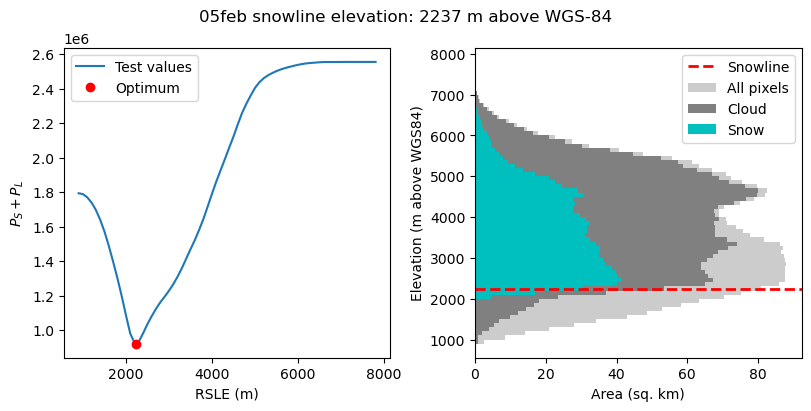

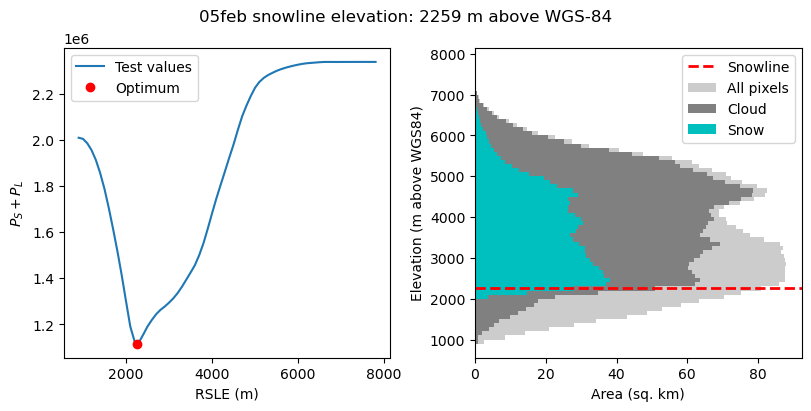

In [8]:
# Test the snowline determination on 100 m elevation steps for both binary and fractional snow cover
result_binary = analyze_snowline("05feb", fractional=False)
result_fractional = analyze_snowline("05feb", fractional=True)

for result in [result_binary, result_fractional]:
        s = f"{result['date']} snowline elevation: {result['snowline']:.4g} m above WGS-84"
        test_elevations = np.arange(result["z1"], result["z2"] + 100, 100)
        test_values = np.array([result["objective"](elevation) for elevation in test_elevations])

        fig, ax = plt.subplots(1,2, figsize=(8, 4), constrained_layout=True)
        ax[0].plot(test_elevations, test_values, "-")
        ax[0].plot(result["snowline"], result["objective"](result["snowline"]), "ro")
        ax[0].set(ylabel=r"$P_S + P_L$", xlabel="RSLE (m)")
        ax[0].legend(["Test values", "Optimum"])

        height = np.diff(result["edges"])
        ax[1].barh(result["centers"], result["all_counts"] * pixel_area_km2, height=height,
                color="0.8", label="All pixels")
        ax[1].barh(result["centers"], (result["cloud_counts"] + result["snow_counts"]) * pixel_area_km2,
                height=height, color="0.5", label="Cloud")
        ax[1].barh(result["centers"], result["snow_counts"] * pixel_area_km2,
                height=height, color="c", label="Snow")
        ax[1].axhline(result["snowline"], color="r", linestyle="--", linewidth=2, label="Snowline")
        ax[1].set(xlabel="Area (sq. km)", ylabel="Elevation (m above WGS84)")
        ax[1].legend()
        plt.suptitle(s)



## Compare the snow cover area distributions

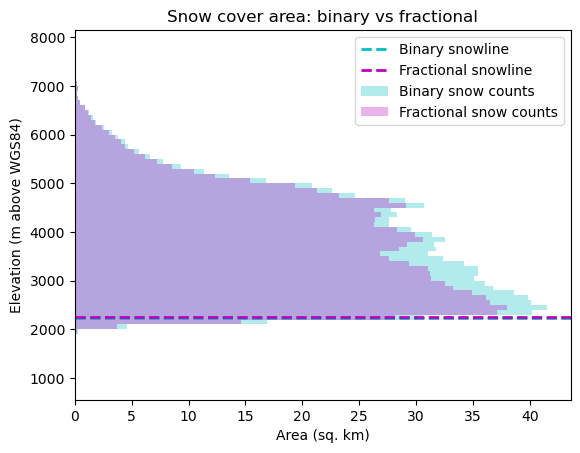

In [ ]:
fig, ax = plt.subplots()
height = np.diff(result_binary["edges"])
ax.barh(result_binary["centers"], result_binary["snow_counts"] * pixel_area_km2, height=height, color="c", label="Binary snow counts", alpha=0.3)
ax.barh(result_fractional["centers"], result_fractional["snow_counts"] * pixel_area_km2, height=height, color="m", label="Fractional snow counts", alpha=0.3)
ax.set(xlabel="Area (sq. km)", ylabel="Elevation (m above WGS84)")
ax.set_title(f"Snow cover area: binary vs fractional")
ax.legend()
# add a vertical line at the snowline for each version
ax.axhline(result_binary["snowline"], color="c", linestyle="--", linewidth=2, label="Binary snowline")
ax.axhline(result_fractional["snowline"], color="m", linestyle="--", linewidth=2, label="Fractional snowline")
ax.legend()
plt.show()